#Transição do perfil de mortalidade por doenças crônicas entre mulheres negras e brancas no Estado de São Paulo (2000–2020)

>*Como o perfil de mortalidade por doenças crônicas entre mulheres negras e brancas mudou entre 2000 e 2020, no Estado de São Paulo?*

O Sistema de Informações sobre Mortalidade (SIM) reúne registros de óbitos ocorridos no Brasil e constitui uma importante fonte para subsidiar políticas públicas de saúde.

Neste estudo foi realizada uma análise exploratória dos registros de mortalidade feminina do Estado de São Paulo nos anos de 2000 e 2020. O objetivo foi investigar possíveis mudanças no perfil das principais doenças crônicas e identificar diferenças entre mulheres negras e brancas que possam subsidiar ações de saúde pública.

## Metodologia e tratamento dos dados

Os dados foram obtidos a partir do Sistema de Informações sobre Mortalidade (SIM) utilizando Python e a biblioteca `PySUS`.. Foram selecionados registros femininos dos anos de 2000 e 2020. Após a extração, realizou-se a seleção das variáveis de interesse, padronização da variável raça/cor e agrupamento das categorias preta e parda na categoria analítica “Negra”. As causas básicas de morte foram classificadas em quatro grupos de doenças crônicas conforme Organização Mundial da Saúde (OMS): Neoplasias (Capítulo C), Doenças Metabólicas (Capítulo E), Doenças Cardiovasculares (Capítulo I) e Doenças Respiratórias Crônicas (Capítulo J). Em seguida, foram calculadas frequências absolutas e proporcionais para comparação entre grupos raciais e períodos analisados.


In [ ]:
!pip install PySUS

In [ ]:
#importação de Bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pysus import sim

In [ ]:
#Leitura do arquivo do SIM 2000
dados2000 = sim(state='SP', year=2000)
dados_brutos2000 = pd.DataFrame(dados2000)
df2000 = pd.read_parquet("/root/pysus/downloads/ducklake/sim/DOSP2000.parquet")
df2000.head()

,contador,TIPOBITO,DTOBITO,NATURAL,DTNASC,IDADE,SEXO,RACACOR,ESTCIV,ESC,OCUP,CODBAIRES,CODMUNRES,LOCOCOR,CODMUNOCOR,IDADEMAE,ESCMAE,OCUPMAE,QTDFILVIVO,QTDFILMORT,GRAVIDEZ,GESTACAO,PARTO,OBITOPARTO,PESO,OBITOGRAV,OBITOPUERP,ASSISTMED,EXAME,CIRURGIA,NECROPSIA,CAUSABAS,LINHAA,LINHAB,LINHAC,LINHAD,LINHAII,CIRCOBITO,ACIDTRAB,FONTE
0,1,2,13072000,,28041947,453,1,,2,,,,3550308,1,1501402,,,,,,,,,,,,,,,,,E148,*J969,*A419,,*E148,,,,
1,2,2,20072000,835,21081954,445,1,,,,,,3518800,1,1501402,,,,,,,,,,,,,,1,2,2,D849,*I490,*R688,*D849,,,,,
2,3,2,03072000,,09111995,404,1,4,1,2,,,3546801,1,1501402,,,,,,,,,,,,,,,,,V099,*G932,*S099,*V099,,,1,,
3,4,2,15102000,,24011923,477,2,,,,,,3550308,3,1501402,,,,,,,,,,,,,,,,,J969,*J969,,,,,,,
4,5,2,07122000,815,26102000,301,2,,1,1,,,3546801,1,1501402,,,,01,00,1,5,1,,2640,,,1,1,2,2,Q000,*R688,*J969,*Q000,,*P399,,,


In [ ]:
# Carregando dados do SIM 2020
dados2020 = sim(state='SP', year=2020)
dados_brutos2020 = pd.DataFrame(dados2020)
df2020 = pd.read_parquet("/root/pysus/downloads/ducklake/sim/DOSP2020.parquet")
df2020.head()

,ORIGEM,TIPOBITO,DTOBITO,HORAOBITO,NATURAL,CODMUNNATU,DTNASC,IDADE,SEXO,RACACOR,ESTCIV,ESC,ESC2010,SERIESCFAL,OCUP,CODMUNRES,LOCOCOR,CODESTAB,ESTABDESCR,CODMUNOCOR,IDADEMAE,ESCMAE,ESCMAE2010,SERIESCMAE,OCUPMAE,QTDFILVIVO,QTDFILMORT,GRAVIDEZ,SEMAGESTAC,GESTACAO,PARTO,OBITOPARTO,PESO,TPMORTEOCO,OBITOGRAV,OBITOPUERP,ASSISTMED,EXAME,CIRURGIA,NECROPSIA,LINHAA,LINHAB,LINHAC,LINHAD,LINHAII,CAUSABAS,CB_PRE,COMUNSVOIM,DTATESTADO,CIRCOBITO,ACIDTRAB,FONTE,NUMEROLOTE,TPPOS,DTINVESTIG,CAUSABAS_O,DTCADASTRO,ATESTANTE,STCODIFICA,CODIFICADO,VERSAOSIST,VERSAOSCB,FONTEINV,DTRECEBIM,ATESTADO,DTRECORIGA,CAUSAMAT,ESCMAEAGR1,ESCFALAGR1,STDOEPIDEM,STDONOVA,DIFDATA,NUDIASOBCO,NUDIASOBIN,DTCADINV,TPOBITOCOR,DTCONINV,FONTES,TPRESGINFO,TPNIVELINV,NUDIASINF,DTCADINF,MORTEPARTO,DTCONCASO,FONTESINF,ALTCAUSA,CONTADOR
0,1,2,05052020,1405,835,354850,12121941,478,1,4,2,3,2,,999993,351870,1,2754843,,351870,,,,,,,,,,,,,,,,,1,,,2,*B342*U071,,,,*I10X,B342,,,05052020,,,,20200095,S,29072020,B342,29072020,2,S,S,3.2.30,3.2,8,30072020,B342 U071*I10,30072020,,,11,0,1,086,,,,,,,,,,,,,,,7
1,1,2,05052020,1406,835,353760,18111942,477,2,1,4,3,2,,752105,351870,2,2789353,,351870,,,,,,,,,,,,,,,,,1,,,2,*B342*U071,,,,*E147,B342,,,05052020,,,,20200095,S,29072020,B342,29072020,2,S,S,3.2.30,3.2,8,30072020,B342 U071*E147,30072020,,,11,0,1,086,,,,,,,,,,,,,,,8
2,1,2,27052020,2242,835,355030,20121942,477,2,1,3,2,1,,999992,355030,3,,,355030,,,,,,,,,,,,,,,,,2,,,2,*R99X,,,,,R99,,,28052020,,,,20210030,,,R99,29072020,5,S,S,3.2.30,3.2,,,R99,30072020,,,10,0,1,063,,,,,,,,,,,,,,,9
3,1,2,25062020,2130,835,353860,20021955,465,1,1,2,2,1,,999993,355030,3,,,355030,,,,,,,,,,,,,,,,,,,,,,,,*I10X,*E119,I10,,,25062020,,,,20210030,,,I10,29072020,5,S,S,3.2.30,3.2,,,/ / /I10*E119,30072020,,,10,0,1,034,,,,,,,,,,,,,,,10
4,1,2,21042020,0732,800,,08101960,459,2,4,4,1,0,,999994,355030,3,,,355030,,,,,,,,,,,,,,,,,1,,,2,*I509,,,,*I10X,I509,,,21042020,,,,20210198,,,I509,29072020,5,S,S,3.2.30,3.2,,,I509*I10,30072020,,,00,0,1,099,,,,,,,,,,,,,,,11


In [ ]:
#concatenação das bases
colunas = ["SEXO", "RACACOR", "CAUSABAS"]
base2000 = df2000[colunas].copy()
base2020 = df2020[colunas].copy()

base2000["ANO"] = 2000
base2020["ANO"] = 2020

df_ano = pd.concat([base2000, base2020],ignore_index=True)
df_ano.head()

,SEXO,RACACOR,CAUSABAS,ANO
0,1,,E148,2000
1,1,,D849,2000
2,1,4,V099,2000
3,2,,J969,2000
4,2,,Q000,2000


In [ ]:
#seleção de mulheres na base
df_mulheres = df_ano[df_ano["SEXO"] == "2"].copy()
df_mulheres.head()

,SEXO,RACACOR,CAUSABAS,ANO
3,2,,J969,2000
4,2,,Q000,2000
12,2,,I429,2000
15,2,2,F102,2000
20,2,1,I351,2000


In [ ]:
df_mulheres["RACACOR"].value_counts()

,count
RACACOR,
1,184403
4,39752
2,15138
,9872
3,5376
5,227


In [ ]:
df_mulheres["RACACOR"].dtype

dtype('O')

In [ ]:
df_mulheres = df_mulheres[df_mulheres["RACACOR"].isin(["1","2", "4"])].copy()
print(df_mulheres)

       SEXO RACACOR CAUSABAS   ANO
15        2       2     F102  2000
20        2       1     I351  2000
25        2       1      D62  2000
29        2       4      R99  2000
31        2       4     A390  2000
...     ...     ...      ...   ...
588580    2       1     B342  2020
588581    2       1     I619  2020
588585    2       1     J988  2020
588587    2       4     J988  2020
588592    2       1     J988  2020

[239293 rows x 4 columns]


In [ ]:
df_mulheres.info()

<class 'pandas.core.frame.DataFrame'>
Index: 239293 entries, 15 to 588592
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   SEXO      239293 non-null  object
 1   RACACOR   239293 non-null  object
 2   CAUSABAS  239293 non-null  object
 3   ANO       239293 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 9.1+ MB


In [ ]:
#Verificando se fiz o recorte corretamente

print("\nconfirmar a coleta de dados 2(feminino):")
print(df_mulheres['SEXO'].unique())

print("\nValores únicos em RACACOR:")
print(df_mulheres['RACACOR'].unique())
print("\nDistribuição entre autodeclaradas Brancas, pretas e pardas:")
print(df_mulheres['RACACOR'].value_counts())


confirmar a coleta de dados 2(feminino):
['2']

Valores únicos em RACACOR:
['2' '1' '4']

Distribuição entre autodeclaradas Brancas, pretas e pardas:
RACACOR
1    184403
4     39752
2     15138
Name: count, dtype: int64


In [ ]:
#Classificação conforme o dicionário de metadados do SIM

etnia = {"1": "Branca", "2": "Negra", "4": "Negra"}

df_mulheres["ETNIA"] = df_mulheres["RACACOR"].map(etnia)
df_mulheres.head()

,SEXO,RACACOR,CAUSABAS,ANO,ETNIA
15,2,2,F102,2000,Negra
20,2,1,I351,2000,Branca
25,2,1,D62,2000,Branca
29,2,4,R99,2000,Negra
31,2,4,A390,2000,Negra


In [ ]:
df_mulheres["ETNIA"].value_counts(dropna=False)

,count
ETNIA,
Branca,184403
Negra,54890


In [ ]:
df_mulheres["CAPÍTULO"] = (df_mulheres["CAUSABAS"].astype(str).str[:1])
df_mulheres[["CAUSABAS","CAPÍTULO"]].head()

,CAUSABAS,CAPÍTULO
15,F102,F
20,I351,I
25,D62,D
29,R99,R
31,A390,A


In [ ]:
cronicas = {
    "C": "Neoplasias (Câncer)",
    "E": "Doenças metabólicas (Diabetes/Obesidade)",
    "I": "Doenças cardiovasculares (AVC/Infarto)",
    "J": "Doenças respiratórias crônicas"
}
df_mulheres["DOENCA_CRONICA"] = (df_mulheres["CAPÍTULO"].map(cronicas))
df_mulheres.head()

,SEXO,RACACOR,CAUSABAS,ANO,ETNIA,DOENCA_CRONICA,CAPÍTULO
15,2,2,F102,2000,Negra,NaN,F
20,2,1,I351,2000,Branca,Doenças cardiovasculares (AVC/Infarto),I
25,2,1,D62,2000,Branca,NaN,D
29,2,4,R99,2000,Negra,NaN,R
31,2,4,A390,2000,Negra,NaN,A


In [ ]:
df_cronicas = df_mulheres[["SEXO", "ANO", "ETNIA","DOENCA_CRONICA"]].dropna()
df_cronicas.head()

,SEXO,ANO,ETNIA,DOENCA_CRONICA
20,2,2000,Branca,Doenças cardiovasculares (AVC/Infarto)
32,2,2000,Branca,Doenças metabólicas (Diabetes/Obesidade)
36,2,2000,Branca,Doenças cardiovasculares (AVC/Infarto)
48,2,2000,Branca,Doenças cardiovasculares (AVC/Infarto)
49,2,2000,Branca,Doenças respiratórias crônicas


In [ ]:
volume_doencas = df_cronicas.groupby(["ANO", "ETNIA", "DOENCA_CRONICA"], as_index=False)["SEXO"].count()
volume_doencas = proporcao_doencas.rename(columns={'SEXO': 'OBITOS'})
volume_doencas.head()

,ANO,ETNIA,DOENCA_CRONICA,OBITOS
0,2000,Branca,Doenças cardiovasculares (AVC/Infarto),25303
1,2000,Branca,Doenças metabólicas (Diabetes/Obesidade),4519
2,2000,Branca,Doenças respiratórias crônicas,8363
3,2000,Branca,Neoplasias (Câncer),12001
4,2000,Negra,Doenças cardiovasculares (AVC/Infarto),5438


## **Resultado 1:** O Panorama Geral (Visão Macro sem Recorte Racial)

> Distribuição das causas de morte por Doenças Crônicas não Transmicíveis (DCNTs) no agregado de toda a população feminina do estado de São Paulo

Foram identificados aproximadamente 239 mil registros de óbitos femininos por doenças crônicas no período analisado.

Em termos gerais, as mulheres brancas representam 77,1% dos registros, enquanto as mulheres negras representam 22,9%.
Embora mulheres negras representem uma parcela menor dos registros analisados, observa-se aumento de sua participação relativa entre 2000 e 2020, passando de 10,4% (10.011) para 15,1% (23.945) dos óbitos registrados por doenças crônicas. Esse resultado sugere mudanças no perfil da mortalidade feminina ao longo do período e reforça a importância de análises desagregadas por raça/cor.

> Para eliminar o viés do tamanho das amostras, calculou-se a participação percentual nas análises seguintes.




In [ ]:
total_obitos = (df_mulheres["SEXO"].count())

# Total por etnia
obitos_etnia = (df_mulheres.groupby("ETNIA")["SEXO"].count())


grafico_volume = pd.DataFrame({
    "GRUPO": [
        "Total de mulheres",
        "Mulheres brancas",
        "Mulheres negras"
    ],
    "OBITOS": [
        total_obitos,
        obitos_etnia["Branca"],
        obitos_etnia["Negra"]
    ]
})

grafico_volume

,GRUPO,OBITOS
0,Total de mulheres,239293
1,Mulheres brancas,184403
2,Mulheres negras,54890


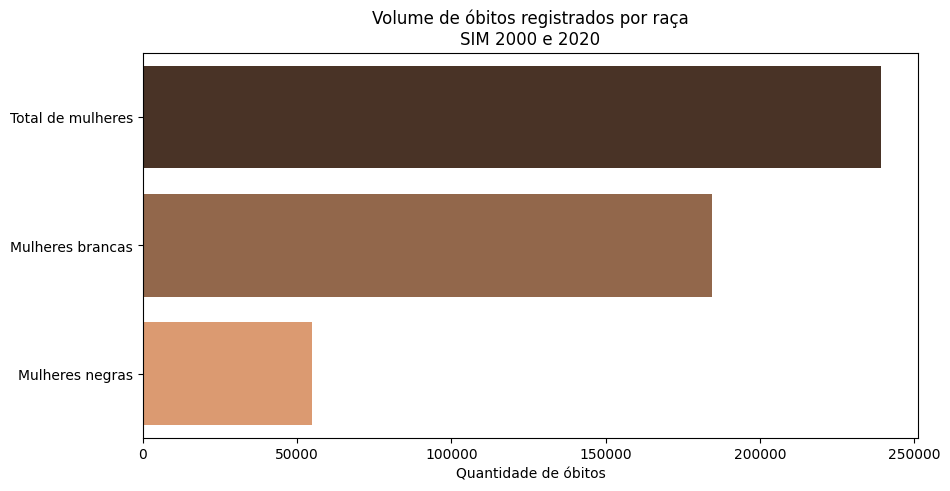

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=grafico_volume,
    y="GRUPO",
    x="OBITOS",
    hue="GRUPO",
    palette="copper",
    legend=False
)

plt.title("Volume de óbitos registrados por raça\nSIM 2000 e 2020")
plt.xlabel("Quantidade de óbitos")
plt.ylabel("")

plt.show()

Isso significa que em 2000 com a quantidade total de 96451 de óbitos registrados, apenas 10011 (10,38%) são de mulheres negras e 2020, num total de 158317,23945(15,12%) pertence às mulheres negras.

Apesar disso, de 2000 para 2020, houve um salto de 10,38% para 15,12% na proporção de óbitos de mulheres negras.

In [ ]:
total_obitos.head()

,ANO,TOTAL_OBITOS
0,2000,96451
1,2020,158317


## **Resultado 2:** Recorte Racial e feminino em mortalidade por Doenças Crônicas

As doenças cardiovasculares foram a principal causa de morte em ambos os grupos raciais nos dois períodos analisados. Entretanto, observa-se maior participação relativa das doenças cardiovasculares entre mulheres negras, enquanto neoplasias apresentam maior participação relativa entre mulheres brancas. Essas diferenças sugerem possíveis desigualdades no perfil epidemiológico e apontam para a necessidade de estratégias preventivas direcionadas a grupos específicos da população.

> A coluna de diferença percentual evidencia quais causas apresentam maior ou menor peso para a população negra feminina, em relação a branca.

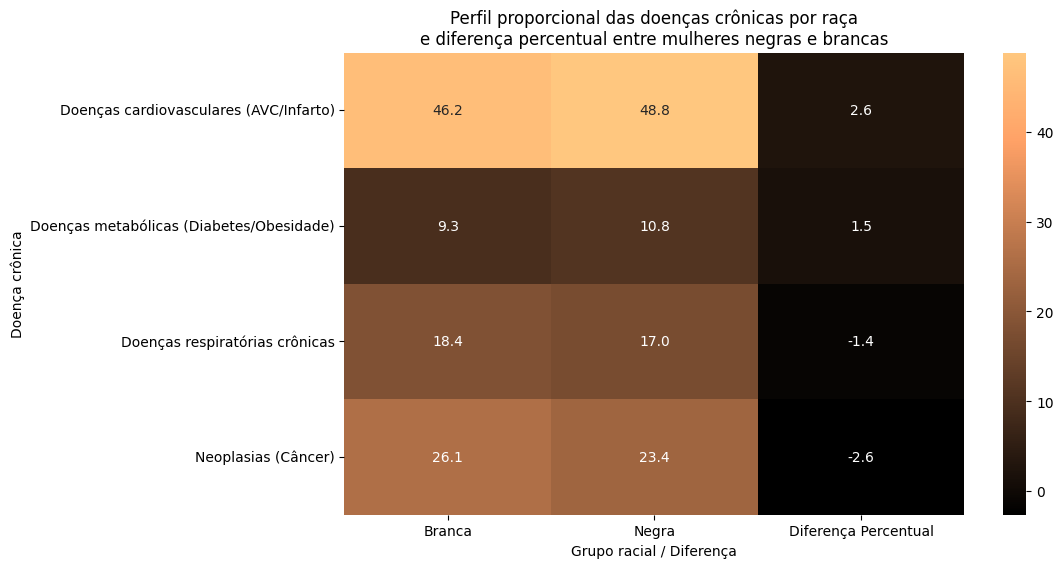

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_dados,
    annot=True,
    fmt=".1f",
    cmap="copper"
)

plt.title("Perfil proporcional das doenças crônicas por raça\n" "e diferença percentual entre mulheres negras e brancas")
plt.xlabel("Grupo racial / Diferença")
plt.ylabel("Doença crônica")
plt.show()

###Códigos que geraram o Headmap

In [ ]:
ano_etnia = (volume_doencas.groupby(["ANO", "ETNIA"],as_index=False)["OBITOS"].sum().rename(columns={"OBITOS": "TOTAL_ETNIA"}))
ano_etnia

,ANO,ETNIA,TOTAL_ETNIA
0,2000,Branca,50186
1,2000,Negra,10011
2,2020,Branca,67890
3,2020,Negra,23945


In [ ]:
volume_doencas = volume_doencas.merge(
    ano_etnia,
    on=["ANO", "ETNIA"],
    how="left"
)

volume_doencas.head(20)

,ANO,ETNIA,DOENCA_CRONICA,OBITOS,TOTAL_ETNIA
0,2000,Branca,Doenças cardiovasculares (AVC/Infarto),25303,50186
1,2000,Branca,Doenças metabólicas (Diabetes/Obesidade),4519,50186
2,2000,Branca,Doenças respiratórias crônicas,8363,50186
3,2000,Branca,Neoplasias (Câncer),12001,50186
4,2000,Negra,Doenças cardiovasculares (AVC/Infarto),5438,10011
5,2000,Negra,Doenças metabólicas (Diabetes/Obesidade),1067,10011
6,2000,Negra,Doenças respiratórias crônicas,1443,10011
7,2000,Negra,Neoplasias (Câncer),2063,10011
8,2020,Branca,Doenças cardiovasculares (AVC/Infarto),28568,67890
9,2020,Branca,Doenças metabólicas (Diabetes/Obesidade),6501,67890


In [ ]:
heatmap_dados = volume_doencas.pivot_table(
    index="DOENCA_CRONICA",
    columns="ETNIA",
    values="PERCENTUAL"
)

heatmap_dados["Diferença Percentual"] = (
    heatmap_dados["Negra"] -
    heatmap_dados["Branca"]
)

heatmap_dados

ETNIA,Branca,Negra,Diferença Percentual
DOENCA_CRONICA,,,
Doenças cardiovasculares (AVC/Infarto),46.249139,48.828531,2.579391
Doenças metabólicas (Diabetes/Obesidade),9.290144,10.766599,1.476455
Doenças respiratórias crônicas,18.373985,16.958586,-1.415399
Neoplasias (Câncer),26.086732,23.446284,-2.640448


A comparação entre os anos de 2000 e 2020 evidencia mudanças no perfil de mortalidade.

Observa-se redução da participação relativa de algumas doenças e aumento de outras, sugerindo uma transição epidemiológica ao longo das duas décadas.

Essas mudanças podem auxiliar na priorização de estratégias de prevenção, rastreamento e acompanhamento clínico de grupos populacionais específicos.

## **Resultado 3:** Transição epidemiológica

Entre 2000 e 2020 observou-se redução da participação das doenças cardiovasculares em ambos os grupos raciais (-8,3 pontos percentuais entre mulheres brancas e -11,0 pontos percentuais entre mulheres negras).

Em contrapartida, houve aumento da participação das neoplasias (+4,3 e +5,7 pontos percentuais, respectivamente) e das doenças respiratórias crônicas (+3,4 e +5,1 pontos percentuais). Esses resultados sugerem uma mudança no perfil das causas de morte ao longo das duas décadas analisadas.

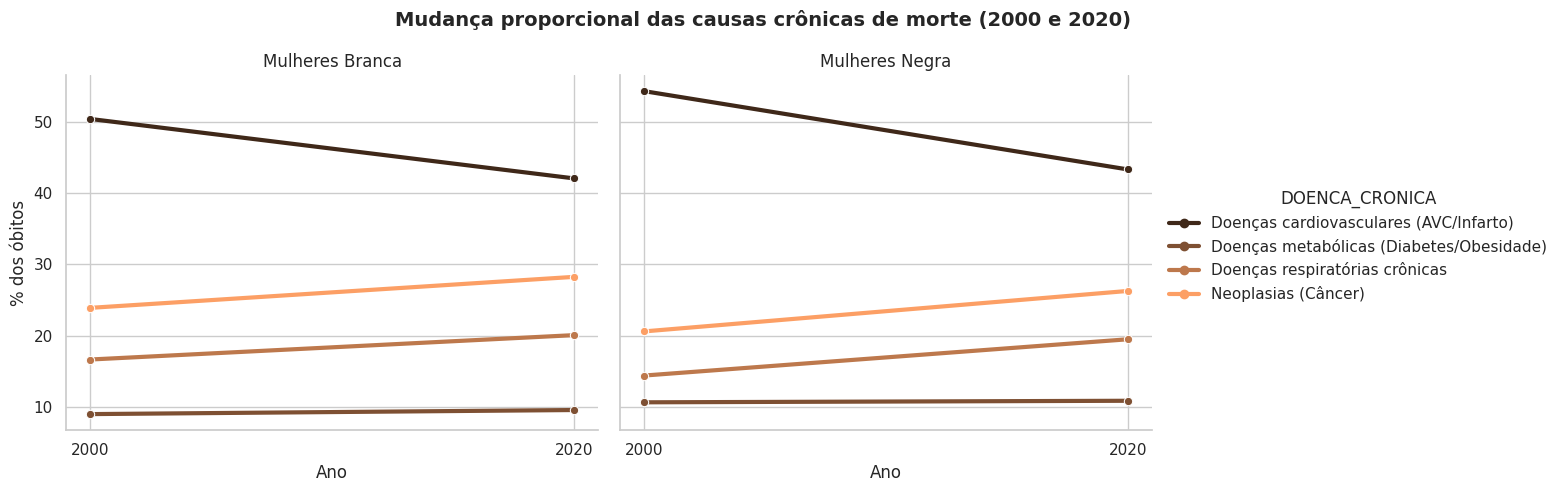

In [ ]:
sns.set_theme(style="whitegrid")
grafico = sns.relplot(
    data=volume_doencas,
    x="ANO",
    y="PERCENTUAL",
    hue="DOENCA_CRONICA",
    col="ETNIA",
    kind="line",
    marker="o",
    linewidth=3,
    palette="copper",
    height=5,
    aspect=1.2
)

grafico.set_titles("Mulheres {col_name}")
grafico.set_axis_labels("Ano", "% dos óbitos")

for ax in grafico.axes.flat:
    ax.set_xticks([2000, 2020])

plt.subplots_adjust(top=0.85)
grafico.fig.suptitle(
    "Mudança proporcional das causas crônicas de morte (2000 e 2020)",
    fontsize=14,
    fontweight='bold'
)

plt.show()

###Códigos que geraram o gráfico de linhas

In [ ]:
volume_doencas["PERCENTUAL"] = (volume_doencas["OBITOS"] / volume_doencas["TOTAL_ETNIA"]) * 100
volume_doencas

,ANO,ETNIA,DOENCA_CRONICA,OBITOS,TOTAL_ETNIA,PERCENTUAL
0,2000,Branca,Doenças cardiovasculares (AVC/Infarto),25303,50186,50.418443
1,2000,Branca,Doenças metabólicas (Diabetes/Obesidade),4519,50186,9.004503
2,2000,Branca,Doenças respiratórias crônicas,8363,50186,16.664010
3,2000,Branca,Neoplasias (Câncer),12001,50186,23.913043
4,2000,Negra,Doenças cardiovasculares (AVC/Infarto),5438,10011,54.320248
5,2000,Negra,Doenças metabólicas (Diabetes/Obesidade),1067,10011,10.658276
6,2000,Negra,Doenças respiratórias crônicas,1443,10011,14.414144
7,2000,Negra,Neoplasias (Câncer),2063,10011,20.607332
8,2020,Branca,Doenças cardiovasculares (AVC/Infarto),28568,67890,42.079835
9,2020,Branca,Doenças metabólicas (Diabetes/Obesidade),6501,67890,9.575784


In [ ]:
variacao_doencas = (
    volume_doencas
    .pivot_table(
        index=["ETNIA", "DOENCA_CRONICA"],
        columns="ANO",
        values="PERCENTUAL"
    )
    .reset_index()
)

variacao_doencas

ANO,ETNIA,DOENCA_CRONICA,2000,2020
0,Branca,Doenças cardiovasculares (AVC/Infarto),50.418443,42.079835
1,Branca,Doenças metabólicas (Diabetes/Obesidade),9.004503,9.575784
2,Branca,Doenças respiratórias crônicas,16.664010,20.083959
3,Branca,Neoplasias (Câncer),23.913043,28.260421
4,Negra,Doenças cardiovasculares (AVC/Infarto),54.320248,43.336814
5,Negra,Doenças metabólicas (Diabetes/Obesidade),10.658276,10.874922
6,Negra,Doenças respiratórias crônicas,14.414144,19.503028
7,Negra,Neoplasias (Câncer),20.607332,26.285237


In [ ]:
variacao_doencas["VARIACAO"] = variacao_doencas[2020] - variacao_doencas[2000]
variacao_doencas = variacao_doencas.round({
    2000: 1,
    2020: 1,
    'VARIACAO': 1
})
variacao_doencas

ANO,ETNIA,DOENCA_CRONICA,2000,2020,VARIACAO
0,Branca,Doenças cardiovasculares (AVC/Infarto),50.4,42.1,-8.3
1,Branca,Doenças metabólicas (Diabetes/Obesidade),9.0,9.6,0.6
2,Branca,Doenças respiratórias crônicas,16.7,20.1,3.4
3,Branca,Neoplasias (Câncer),23.9,28.3,4.3
4,Negra,Doenças cardiovasculares (AVC/Infarto),54.3,43.3,-11.0
5,Negra,Doenças metabólicas (Diabetes/Obesidade),10.7,10.9,0.2
6,Negra,Doenças respiratórias crônicas,14.4,19.5,5.1
7,Negra,Neoplasias (Câncer),20.6,26.3,5.7


#Conclusão

A análise demonstrou que as doenças cardiovasculares permaneceram como a principal causa de mortalidade entre mulheres negras e brancas no Estado de São Paulo em 2000 e 2020. No entanto, observou-se uma redução da participação relativa dessas causas ao longo do período, acompanhada pelo aumento da participação das neoplasias e das doenças respiratórias crônicas.

Também foram identificadas diferenças no perfil proporcional das causas de morte entre mulheres negras e brancas, evidenciando a importância de incorporar o recorte racial no monitoramento de indicadores de saúde.

Esses resultados podem subsidiar ações de prevenção, rastreamento e promoção da saúde voltadas para grupos populacionais específicos, contribuindo para o planejamento de políticas públicas mais equitativas.